## Ejemplo Decision Tree MNIST
<div style="border-style:groove;border-width:thin;padding:10px">
MNIST es un dataset de 70000 dígitos numéricos escritos a mano por empleados del censo y por estudiantes de instituto de EEUU. Para poder trabajar con él, las imágenes están digitalizadas y reducidas a 28x28 pixels en blanco y negro. El objetivo de esta actividad es entrenar un modelo de clasificación que consiga determinar de que número se trata en función de los 784 datos de entrada (28x28). Cada pixel se trata como una entrada al sistema. La salida será el número del 0 al 9 que identifica. 
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
A continuación vamos a importar el dataset y a generar los conjuntos X e y.
    </div>

In [34]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [35]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


<div style="border-style:groove;border-width:thin;padding:10px">
Ahora vamos a coger una muestra cualquiera y a pintarlo. Los datos están como un array de una dimensión y 784 valores. Hay que cambiarlos a un array de dos dimensiones de 28x28 para poder pintarlo como una imagen. 
    </div>

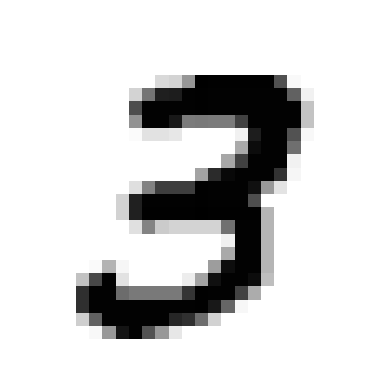

3


In [36]:
import matplotlib as mpl
import matplotlib.pyplot as plt


some_digit = X.iloc[[7]].values
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

print(y[7])

<div style="border-style:groove;border-width:thin;padding:10px">
Es tu turno! Trata de resolver el problema con un árbol de decisión siguiendo los pasos que se indican a continuación:
    </div>

In [37]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import export_graphviz
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

<div style="border-style:groove;border-width:thin;padding:10px">
1. Divide el dataset en el conjunto de entrenamiento y de test.
    </div>

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

<div style="border-style:groove;border-width:thin;padding:10px">
2. Crea un árbol de decisión con los parámetros que quieras e intenta mostrar el gráfico del árbol.
    </div>

In [39]:
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)

export_graphviz(
    tree_clf,
    out_file="./mnis_tree.dot",
    feature_names=mnist.feature_names,
    # use the trained classifier's classes_ (converted to strings) so the length matches the tree classes
    class_names=[str(c) for c in tree_clf.classes_],
    rounded=True,
    filled=True
)

# If "dot: command not found" occurs, install graphviz in the system:
# sudo apt install graphviz
!dot -Tpng mnis_tree.dot -o mnis_tree.png

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.062214 to fit


<div style="border-style:groove;border-width:thin;padding:10px">
3. Genera la predicción (y_pred) con el árbol entrenado y mira la precisión que has conseguido. Módifica los hiperparámetros del árbol en el código del punto 2 para mejorar los resultados.
    </div>

In [40]:
y_pred = tree_clf.predict(X_test)
print(y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

['7' '3' '1' ... '6' '2' '5']
Accuracy: 0.8743571428571428


<div style="border-style:groove;border-width:thin;padding:10px">
4. Recorre la muestra de test viendo los datos que son erróneos y muestra la imagen. Evalúa si el resultado es suficientemente bueno.
</div>

📊 ANÁLISIS DE ERRORES DEL ÁRBOL DE DECISIÓN
Total de muestras de test: 14000
Total de errores: 1759
Tasa de error: 12.56%
Tasa de acierto: 87.44%


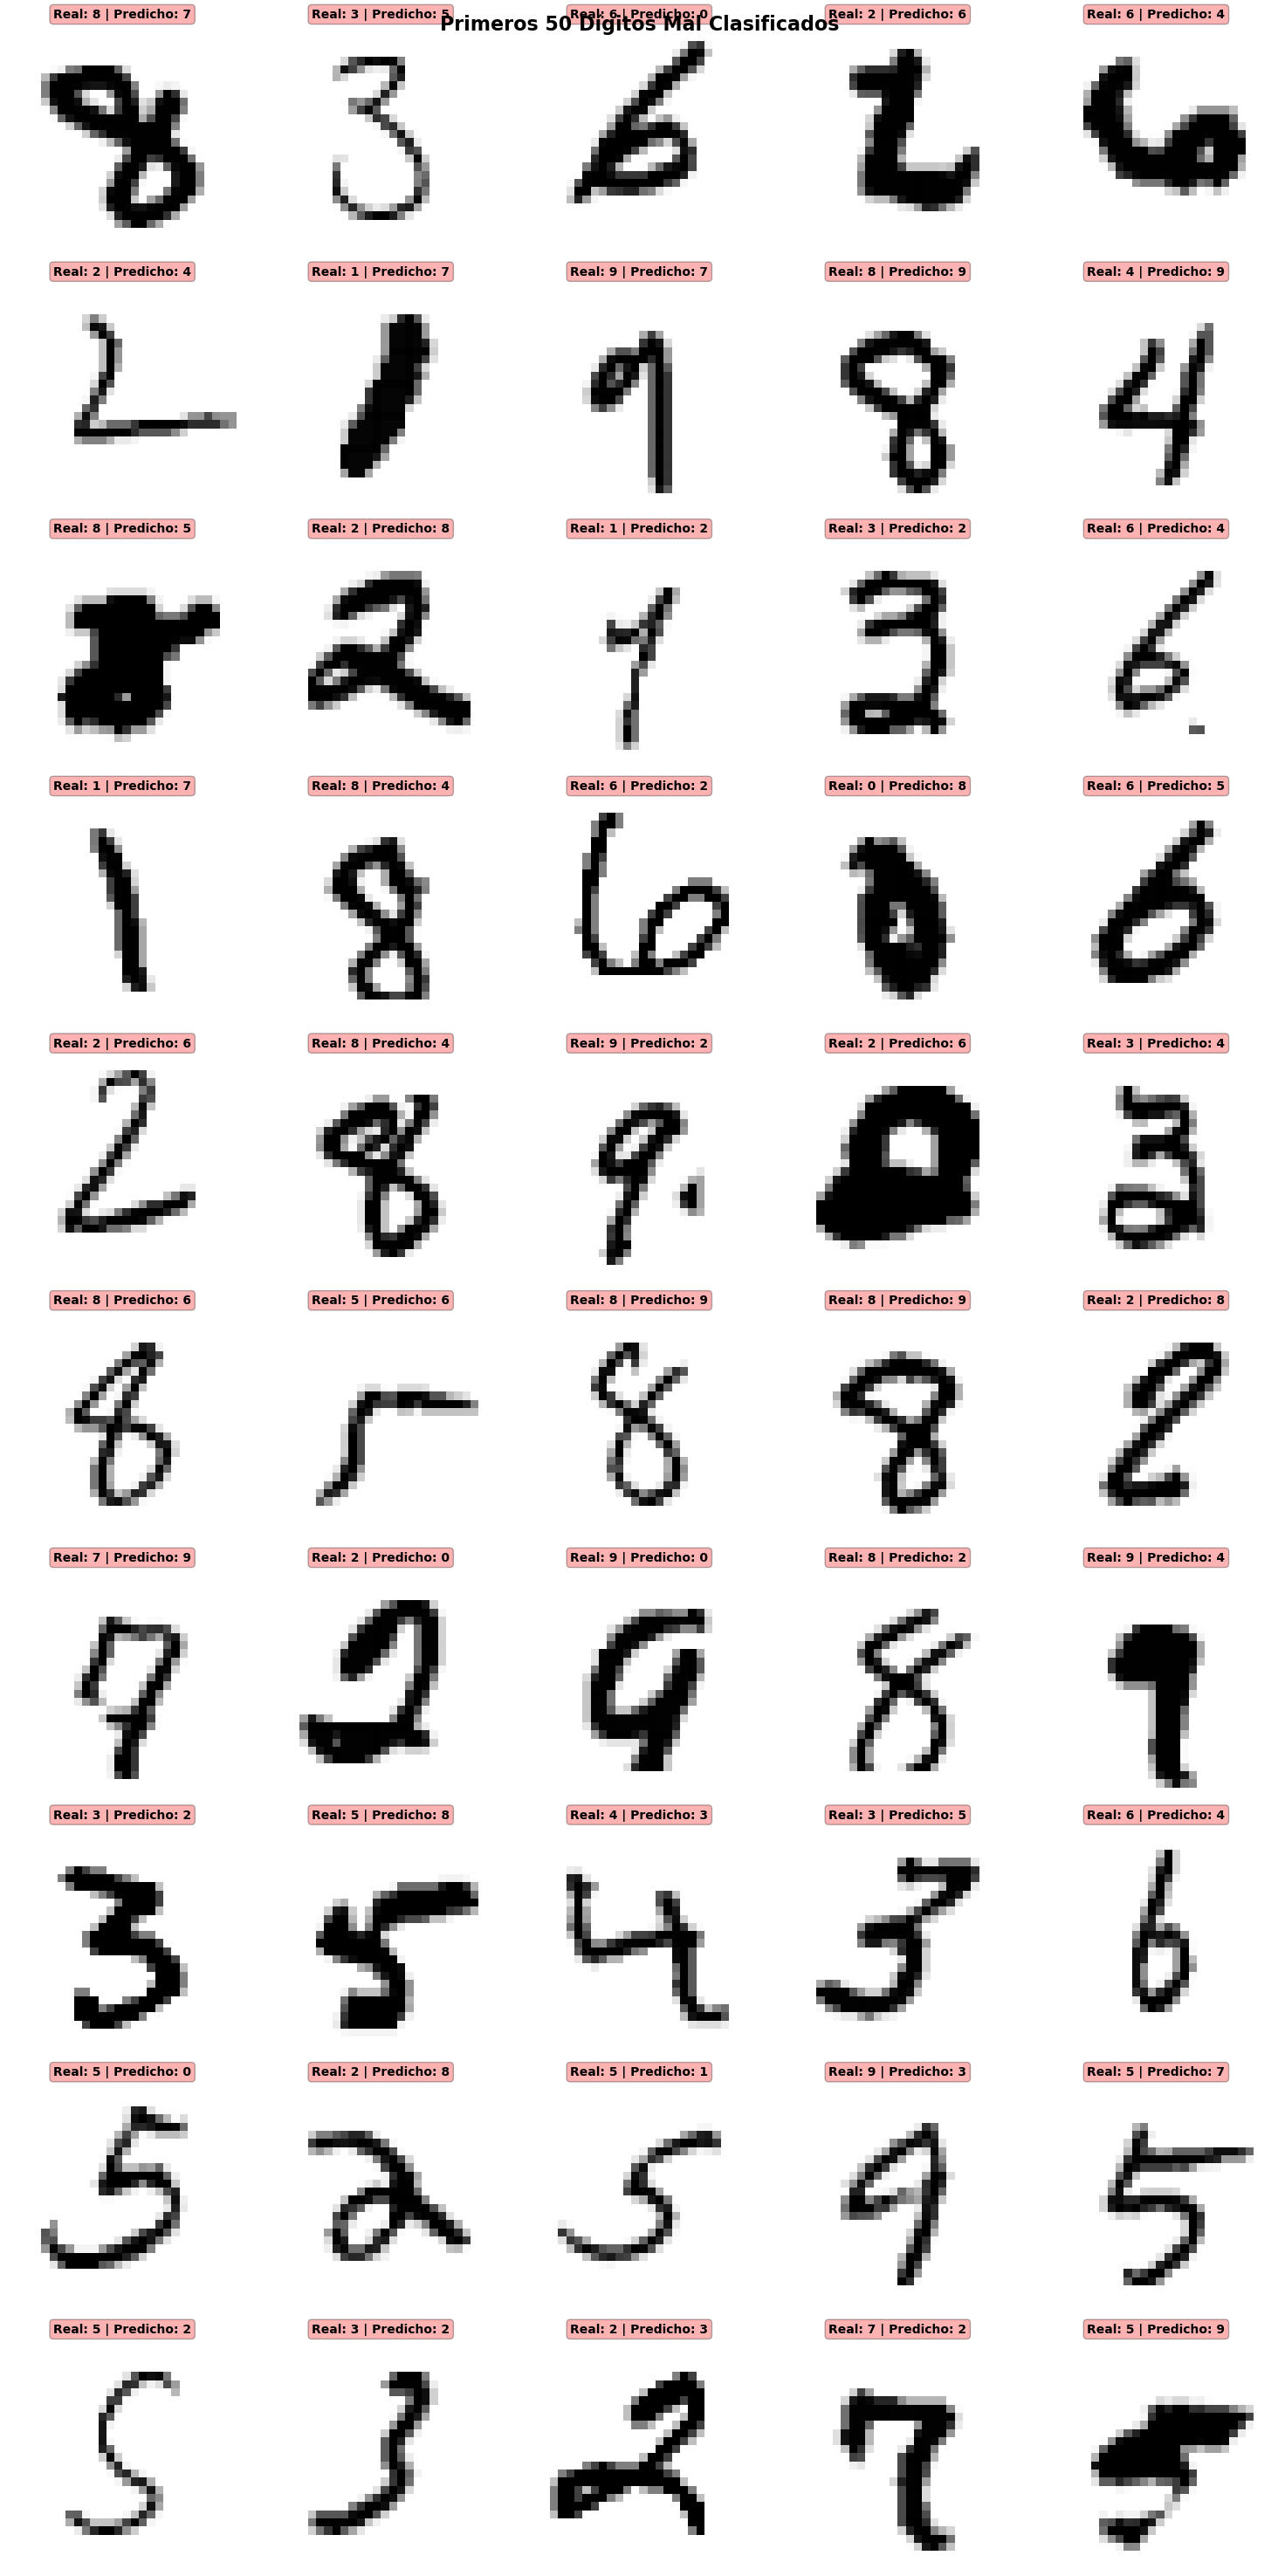


📈 ANÁLISIS DETALLADO DE CONFUSIONES:
--------------------------------------------------------------------------------

Top 10 confusiones más frecuentes:
   1. Dígito 9 predicho como 4:  70 veces
   2. Dígito 4 predicho como 9:  69 veces
   3. Dígito 3 predicho como 5:  58 veces
   4. Dígito 5 predicho como 3:  52 veces
   5. Dígito 8 predicho como 3:  48 veces
   6. Dígito 8 predicho como 5:  44 veces
   7. Dígito 2 predicho como 3:  40 veces
   8. Dígito 7 predicho como 9:  39 veces
   9. Dígito 3 predicho como 2:  38 veces
  10. Dígito 6 predicho como 5:  38 veces

📋 EVALUACIÓN DEL RESULTADO:


In [41]:
# Encontrar índices de errores
errors = y_test != y_pred
error_indices = np.where(errors)[0]

print(f"📊 ANÁLISIS DE ERRORES DEL ÁRBOL DE DECISIÓN")
print("=" * 80)
print(f"Total de muestras de test: {len(y_test)}")
print(f"Total de errores: {len(error_indices)}")
print(f"Tasa de error: {len(error_indices)/len(y_test)*100:.2f}%")
print(f"Tasa de acierto: {(1 - len(error_indices)/len(y_test))*100:.2f}%")
print("=" * 80)

# Número de errores a mostrar (configurable)
num_errors_to_show = min(50, len(error_indices))  # Cambiar 20 por el número que quieras

# Calcular dimensiones de la grid
cols = 5
rows = (num_errors_to_show + cols - 1) // cols  # Redondear hacia arriba

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
fig.suptitle(f'Primeros {num_errors_to_show} Dígitos Mal Clasificados', 
             fontsize=16, fontweight='bold')

# Aplanar axes si es necesario
if rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for i, idx in enumerate(error_indices[:num_errors_to_show]):
    # Obtener la imagen
    digit_image = X_test.iloc[idx].values.reshape(28, 28)
    
    # Plotear
    axes[i].imshow(digit_image, cmap="binary")
    axes[i].axis("off")
    
    # Título con predicción vs real
    true_label = int(y_test.iloc[idx])
    pred_label = int(y_pred[idx])
    
    title = f"Real: {true_label} | Predicho: {pred_label}"
    axes[i].set_title(title, fontsize=10, fontweight='bold', 
                      bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# Ocultar axes sobrantes si existen
for i in range(num_errors_to_show, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Análisis detallado de confusiones
print("\n📈 ANÁLISIS DETALLADO DE CONFUSIONES:")
print("-" * 80)

# Mostrar pares de confusión más comunes
from collections import Counter
confusion_pairs = []

for idx in error_indices:
    true_label = int(y_test.iloc[idx])
    pred_label = int(y_pred[idx])
    confusion_pairs.append((true_label, pred_label))

most_common_confusions = Counter(confusion_pairs).most_common(10)

print("\nTop 10 confusiones más frecuentes:")
for i, ((true_label, pred_label), count) in enumerate(most_common_confusions, 1):
    print(f"  {i:2}. Dígito {true_label} predicho como {pred_label}: {count:3} veces")

# Evaluación general
print("\n" + "=" * 80)
print("📋 EVALUACIÓN DEL RESULTADO:")
print("=" * 80)

accuracy = accuracy_score(y_test, y_pred)

<div style="border-style:groove;border-width:thin;padding:10px">
5. Prueba ahora a resolver el problema con SVM. 
    </div>

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm_poly = SVC(kernel="linear", degree=4, coef0=1, C=5.0)

#svm_lineal.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)

#pred_lineal = svm_lineal.predict(X_test_scaled)
pred_rbf = svm_poly.predict(X_test_scaled)

In [47]:
print("\n=== SVM Poly ===")
print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))


=== SVM Poly ===
Accuracy: 0.9765142857142857
[[1717    1    0    0    0    0    3    0    2    3]
 [   0 1951    7    0    1    1    1    4    3    1]
 [   6    2 1710    4    7    0    2    8    8    1]
 [   1    3   16 1734    1   10    0    8    9    3]
 [   3    4    8    0 1653    1    5    6    1   25]
 [   5    0    1   14    2 1533   13    0    7    3]
 [   9    3    3    0    4    6 1692    0    2    0]
 [   3    6   12    2   15    0    0 1769    1   15]
 [   5    3    9    4    7   14    4    3 1653    4]
 [   2    6    2    8   16    5    1   15    8 1677]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1726
           1       0.99      0.99      0.99      1969
           2       0.97      0.98      0.97      1748
           3       0.98      0.97      0.98      1785
           4       0.97      0.97      0.97      1706
           5       0.98      0.97      0.97      1578
           6       0.98      0.98      0.98